# Classification Models on Wine Dataset using Python OOP
- Cyber Shujaa Program - Classification Models on Wine Dataset using Python OOP
- Author: Amidu Dabor
- 📅 Date: 7 July 2025

---

# Objective
Apply an understanding of supervised classification models by training and evaluating six models using the Wine dataset from Scikit-learn.
You’ll compare the performance of:

- Logistic Regression

- Decision Tree

- Random Forest

- K-Nearest Neighbors (KNN)

- Naive Bayes

- Support Vector Machine (SVM)

---

## 📚 Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from matplotlib.colors import ListedColormap
sns.set_theme(style="whitegrid")


## 🧱 Define the WineClassifier Class

In [2]:
class WineClassifier:
    def __init__(self) -> None:
        # Load dataset
        wine = load_wine()
        self.dataset = pd.DataFrame(wine.data, columns=wine.feature_names)
        self.dataset['target'] = wine.target
        self.feature_names = wine.feature_names[:2]
        self.target_names = wine.target_names

        # Track model results
        self.results = []

        # EDA
        print("✅ Dataset loaded successfully.")
        print("\n📌 First 5 rows of the dataset:")
        print(self.dataset.head())

        print("\n🧠 Dataset Information:")
        print(self.dataset.info())

        print("\n📉 Summary Statistics:")
        print(self.dataset.describe())

        print("\n❓ Missing Values Check:")
        print(self.dataset.isnull().sum())

        print("\n📊 Class Distribution:")
        print(self.dataset['target'].value_counts())

        self.dataset['target'].value_counts().plot(
            kind='bar',
            title='Wine Class Distribution',
            color=['red', 'green', 'blue']
        )
        plt.xlabel('Wine Class')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Feature selection for 2D visualization
        X = self.dataset.iloc[:, :2].values
        y = self.dataset['target'].values

        # Standardization
        self.sc = StandardScaler()
        X_scaled = self.sc.fit_transform(X)

        # Train/test split
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=0
        )
        print("\n📦 Data has been scaled and split into training and test sets.")

    def train_and_visualize(self, classifier, model_name: str) -> None:
        classifier.fit(self.X_train, self.y_train)
        y_pred = classifier.predict(self.X_test)

        # Accuracy
        accuracy = accuracy_score(self.y_test, y_pred)
        print(f"\n🔍 {model_name} Accuracy Score: {accuracy:.4f}")

        # Classification report
        report = classification_report(self.y_test, y_pred, target_names=self.target_names)
        print(f"\n📄 {model_name} Classification Report:\n{report}")

        # Confusion matrix
        cm = confusion_matrix(self.y_test, y_pred)
        cm_df = pd.DataFrame(cm, index=[f"Class {i}" for i in range(cm.shape[0])],
                             columns=[f"Predicted {i}" for i in range(cm.shape[1])])
        print(f"\n📊 {model_name} Confusion Matrix Table:\n{cm_df}")

        # Heatmap
        self.__plot_confusion_matrix(cm, model_name)

        # Binary summary if 2-class
        if cm.shape == (2, 2):
            cm_summary = pd.DataFrame(
                cm,
                index=['Wrong Prediction', 'Correct Prediction'],
                columns=['Predicted No', 'Predicted Yes']
            )
            print(f"\n📋 {model_name} Binary Confusion Matrix Summary Table:\n{cm_summary}")

        # Save metrics for comparison
        report_dict = classification_report(self.y_test, y_pred, output_dict=True, zero_division=0)
        self.results.append({
            'Model': model_name,
            'Accuracy': accuracy,
            'Precision (macro avg)': report_dict['macro avg']['precision'],
            'Recall (macro avg)': report_dict['macro avg']['recall'],
            'F1-Score (macro avg)': report_dict['macro avg']['f1-score']
        })

        # Plots
        self.__plot_decision_boundary(classifier, self.X_train, self.y_train, model_name, "Training Set")
        self.__plot_decision_boundary(classifier, self.X_test, self.y_test, model_name, "Test Set")

    def __plot_confusion_matrix(self, cm: np.ndarray, model_name: str) -> None:
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=self.target_names, yticklabels=self.target_names)
        plt.title(f'Confusion Matrix - {model_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

    def __plot_decision_boundary(self, classifier, X_set, y_set, model_name, set_type) -> None:
        X_inv = self.sc.inverse_transform(X_set)
        X1, X2 = np.meshgrid(
            np.arange(start=X_inv[:, 0].min() - 1, stop=X_inv[:, 0].max() + 1, step=0.01),
            np.arange(start=X_inv[:, 1].min() - 1, stop=X_inv[:, 1].max() + 1, step=0.01)
        )
        Z = classifier.predict(self.sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape)

        plt.figure(figsize=(8, 5))
        plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(('red', 'green', 'blue')))
        plt.xlim(X1.min(), X1.max())
        plt.ylim(X2.min(), X2.max())

        for i, j in enumerate(np.unique(y_set)):
            plt.scatter(
                X_inv[y_set == j, 0],
                X_inv[y_set == j, 1],
                color=ListedColormap(('red', 'green', 'blue'))(i),
                label=self.target_names[j]
            )

        plt.title(f'{model_name} ({set_type})')
        plt.xlabel(self.feature_names[0].title())
        plt.ylabel(self.feature_names[1].title())
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


## 📈 Define the Comparison Function

In [3]:
def compare_models(wc: WineClassifier) -> pd.DataFrame:
    df_results = pd.DataFrame(wc.results)
    df_sorted = df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

    print("\n📊 Model Comparison Summary:\n")
    display(df_sorted.style.background_gradient(cmap="Greens", axis=0))

    best_model = df_sorted.iloc[0]
    print(f"\n🏆 Best Performing Model: {best_model['Model']}")
    print(f"Accuracy: {best_model['Accuracy']:.4f}")
    print(f"Precision: {best_model['Precision (macro avg)']:.4f}")
    print(f"Recall: {best_model['Recall (macro avg)']:.4f}")
    print(f"F1-Score: {best_model['F1-Score (macro avg)']:.4f}")

    return df_sorted


## 🧪 Train & Evaluate Each Classifier

✅ Dataset loaded successfully.

📌 First 5 rows of the dataset:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   


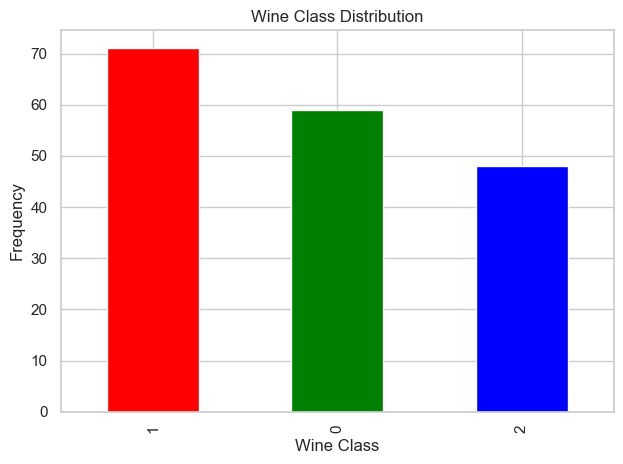


📦 Data has been scaled and split into training and test sets.


In [4]:
# Instantiate engine
wc = WineClassifier()

### 🔹 Logistic Regression


🔍 Logistic Regression Accuracy Score: 0.7222

📄 Logistic Regression Classification Report:
              precision    recall  f1-score   support

     class_0       0.71      0.71      0.71        14
     class_1       0.87      0.81      0.84        16
     class_2       0.43      0.50      0.46         6

    accuracy                           0.72        36
   macro avg       0.67      0.68      0.67        36
weighted avg       0.73      0.72      0.73        36


📊 Logistic Regression Confusion Matrix Table:
         Predicted 0  Predicted 1  Predicted 2
Class 0           10            2            2
Class 1            1           13            2
Class 2            3            0            3


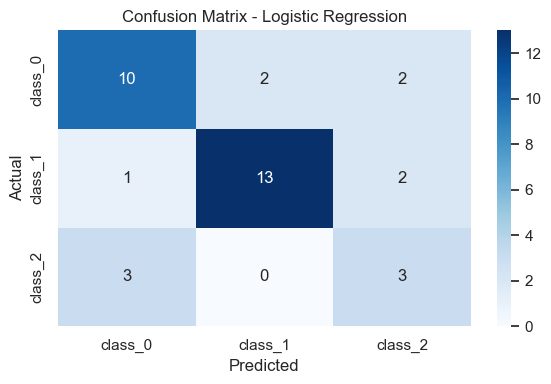

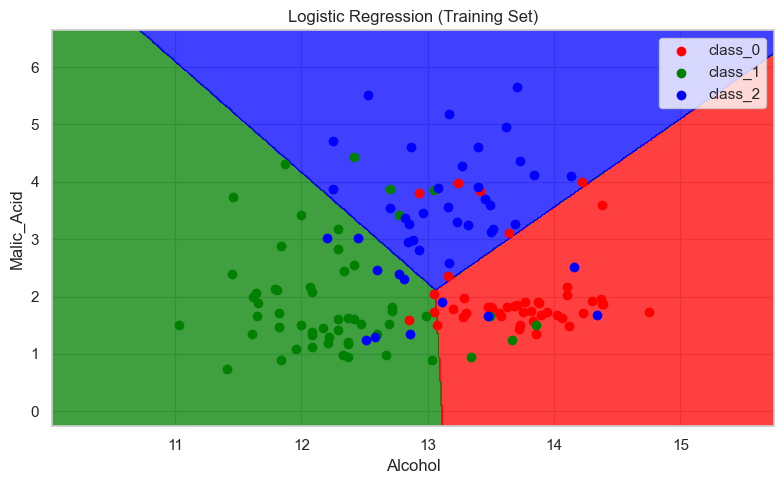

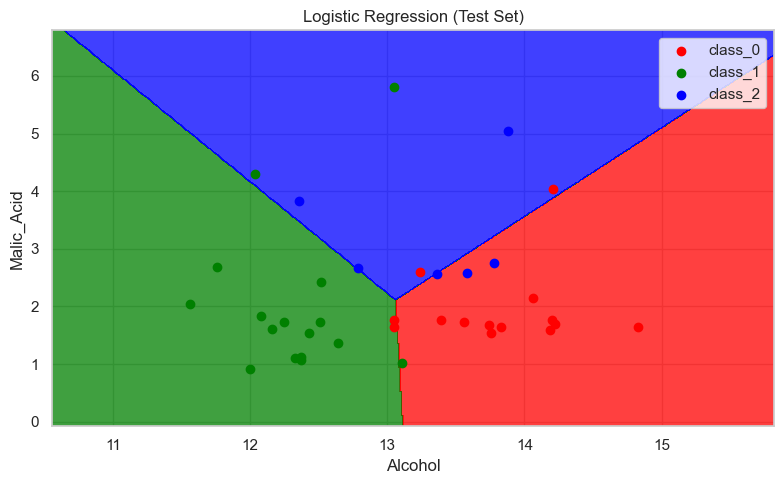

In [5]:
lr = LogisticRegression(random_state=0)
wc.train_and_visualize(lr, "Logistic Regression")

### 🔹 Decision Tree


🔍 Decision Tree Accuracy Score: 0.8056

📄 Decision Tree Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      0.79      0.88        14
     class_1       0.87      0.81      0.84        16
     class_2       0.50      0.83      0.62         6

    accuracy                           0.81        36
   macro avg       0.79      0.81      0.78        36
weighted avg       0.86      0.81      0.82        36


📊 Decision Tree Confusion Matrix Table:
         Predicted 0  Predicted 1  Predicted 2
Class 0           11            1            2
Class 1            0           13            3
Class 2            0            1            5


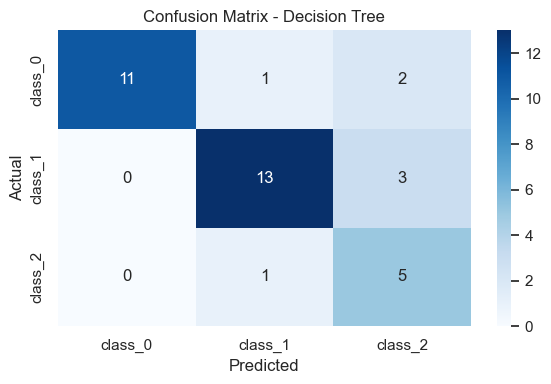

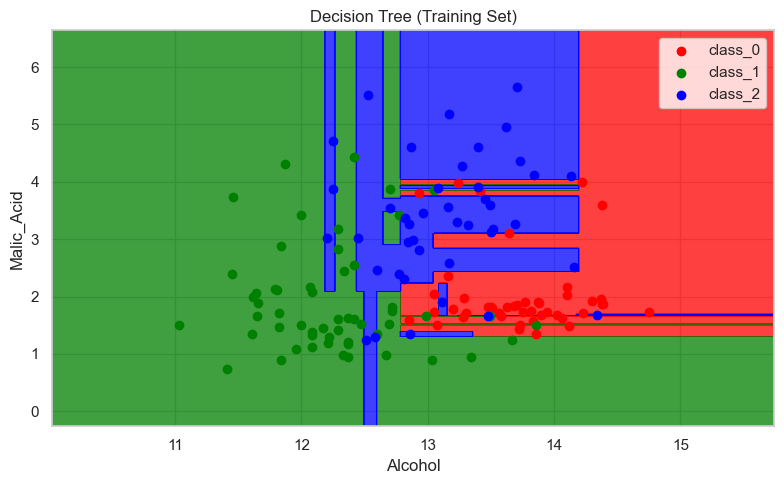

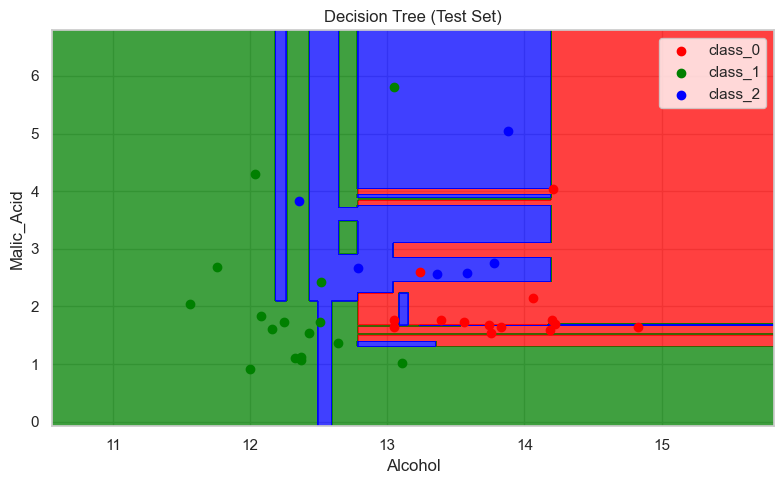

In [6]:
dt = DecisionTreeClassifier(criterion='entropy', random_state=0)
wc.train_and_visualize(dt, "Decision Tree")

### 🔹 Random Forest


🔍 Random Forest Accuracy Score: 0.8889

📄 Random Forest Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      0.93      0.96        14
     class_1       0.93      0.88      0.90        16
     class_2       0.62      0.83      0.71         6

    accuracy                           0.89        36
   macro avg       0.85      0.88      0.86        36
weighted avg       0.91      0.89      0.89        36


📊 Random Forest Confusion Matrix Table:
         Predicted 0  Predicted 1  Predicted 2
Class 0           13            0            1
Class 1            0           14            2
Class 2            0            1            5


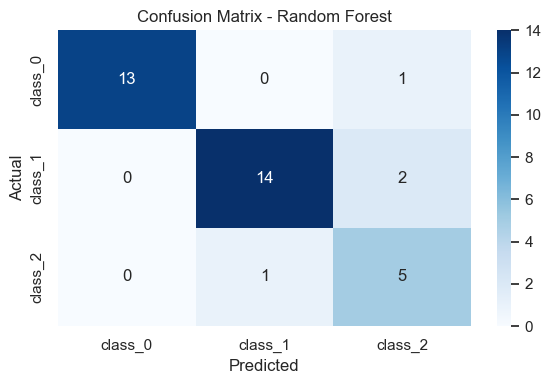

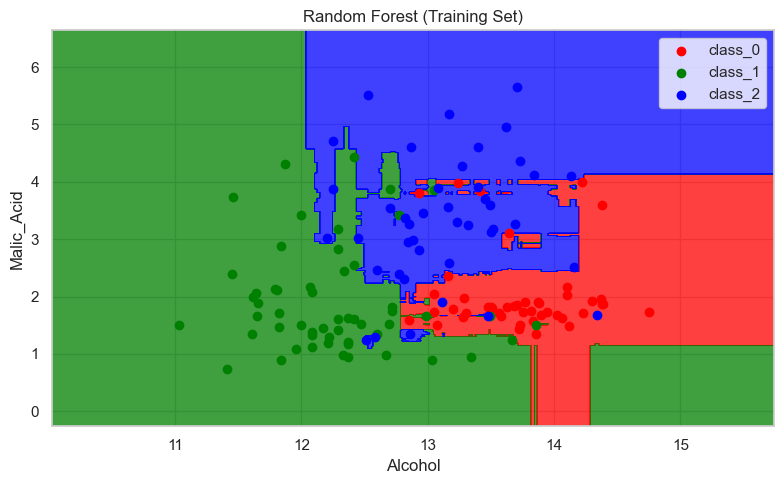

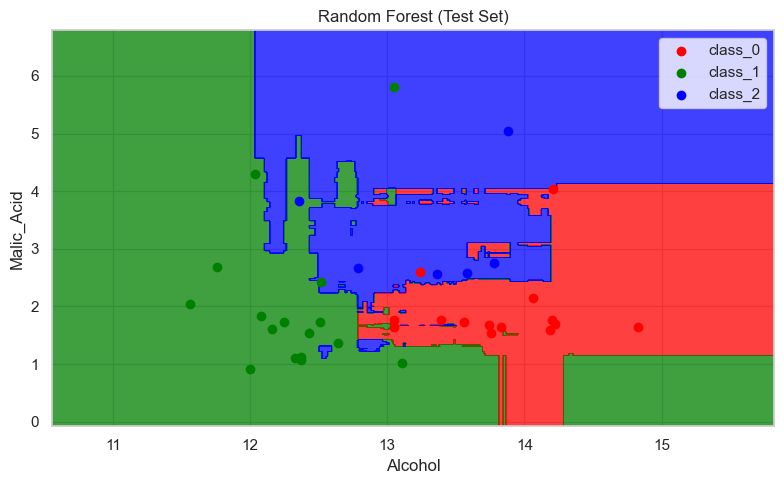

In [7]:
rf = RandomForestClassifier(n_estimators=50, criterion='entropy', random_state=0)
wc.train_and_visualize(rf, "Random Forest")

### 🔹 K-Nearest Neighbors


🔍 K-Nearest Neighbors Accuracy Score: 0.8889

📄 K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      0.93      0.96        14
     class_1       0.93      0.88      0.90        16
     class_2       0.62      0.83      0.71         6

    accuracy                           0.89        36
   macro avg       0.85      0.88      0.86        36
weighted avg       0.91      0.89      0.89        36


📊 K-Nearest Neighbors Confusion Matrix Table:
         Predicted 0  Predicted 1  Predicted 2
Class 0           13            0            1
Class 1            0           14            2
Class 2            0            1            5


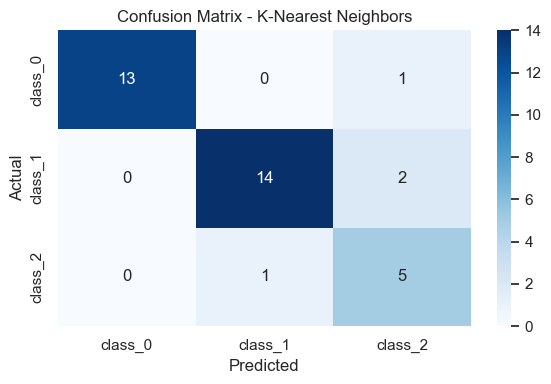

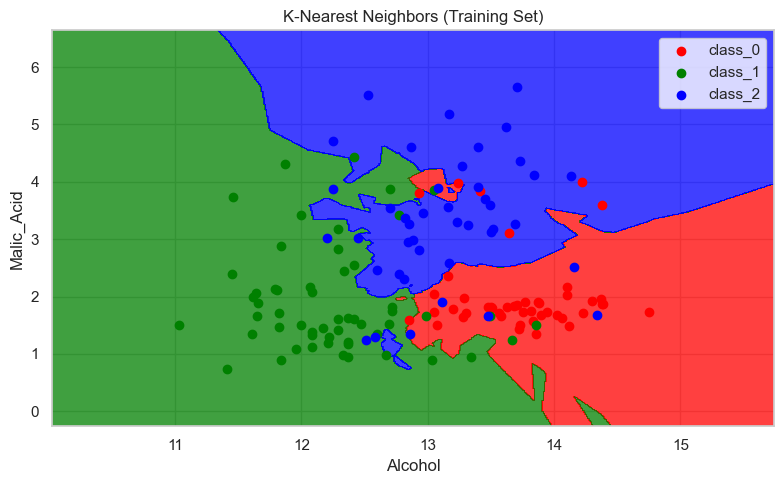

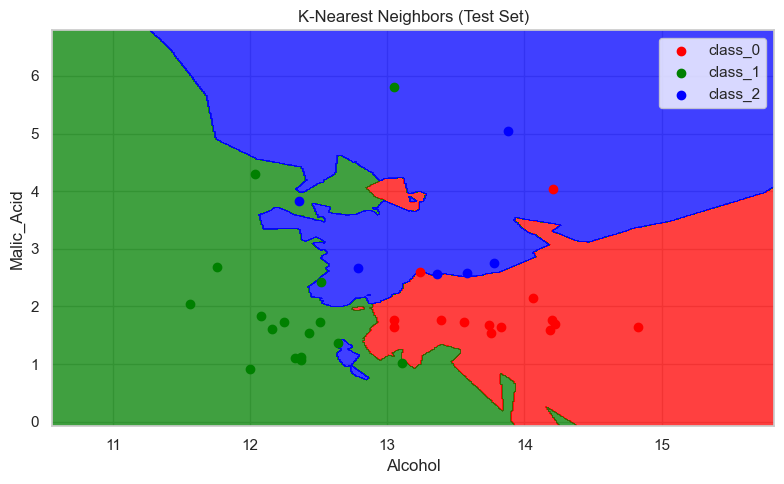

In [8]:
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
wc.train_and_visualize(knn, "K-Nearest Neighbors")

### 🔹 Naive Bayes


🔍 Naive Bayes Accuracy Score: 0.8333

📄 Naive Bayes Classification Report:
              precision    recall  f1-score   support

     class_0       0.81      0.93      0.87        14
     class_1       1.00      0.88      0.93        16
     class_2       0.50      0.50      0.50         6

    accuracy                           0.83        36
   macro avg       0.77      0.77      0.77        36
weighted avg       0.84      0.83      0.84        36


📊 Naive Bayes Confusion Matrix Table:
         Predicted 0  Predicted 1  Predicted 2
Class 0           13            0            1
Class 1            0           14            2
Class 2            3            0            3


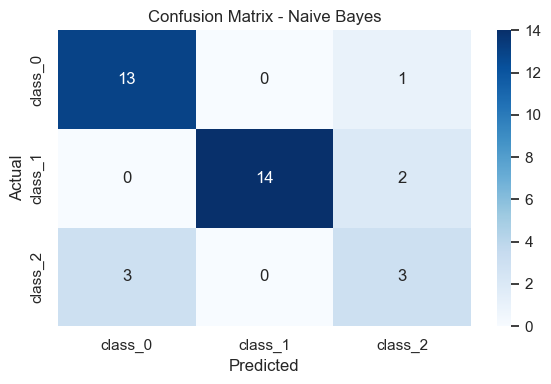

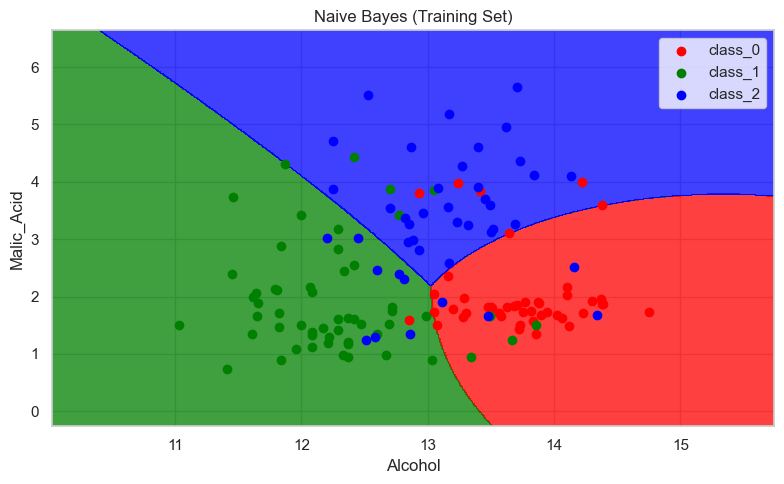

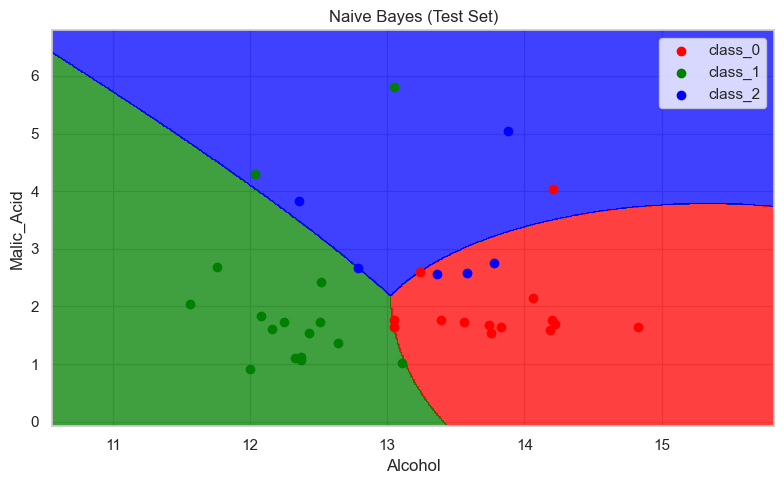

In [9]:
nb = GaussianNB()
wc.train_and_visualize(nb, "Naive Bayes")

### 🔹 Support Vector Machine (SVM)


🔍 Support Vector Machine Accuracy Score: 0.7778

📄 Support Vector Machine Classification Report:
              precision    recall  f1-score   support

     class_0       0.83      0.71      0.77        14
     class_1       0.88      0.88      0.88        16
     class_2       0.50      0.67      0.57         6

    accuracy                           0.78        36
   macro avg       0.74      0.75      0.74        36
weighted avg       0.80      0.78      0.78        36


📊 Support Vector Machine Confusion Matrix Table:
         Predicted 0  Predicted 1  Predicted 2
Class 0           10            2            2
Class 1            0           14            2
Class 2            2            0            4


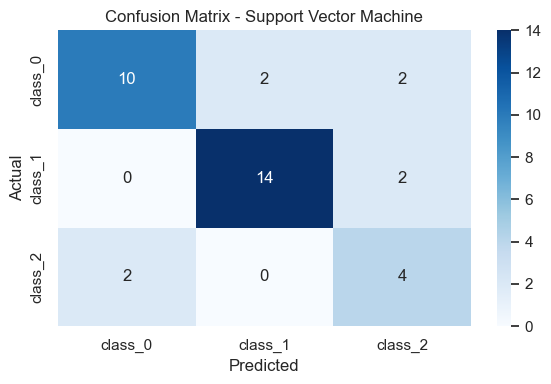

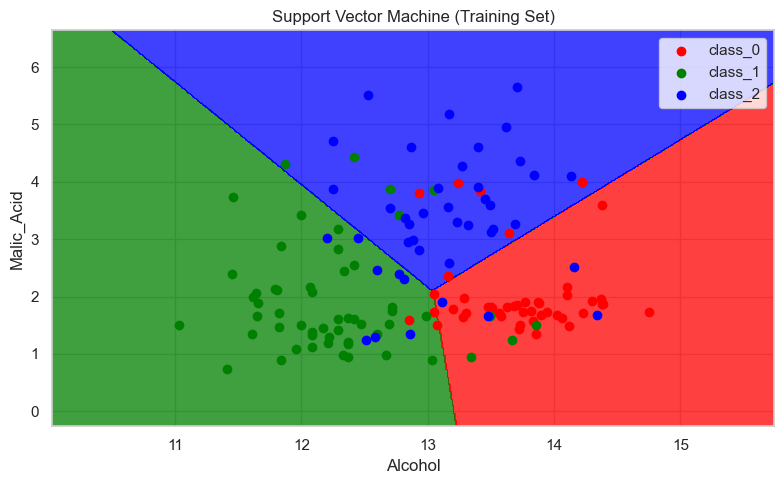

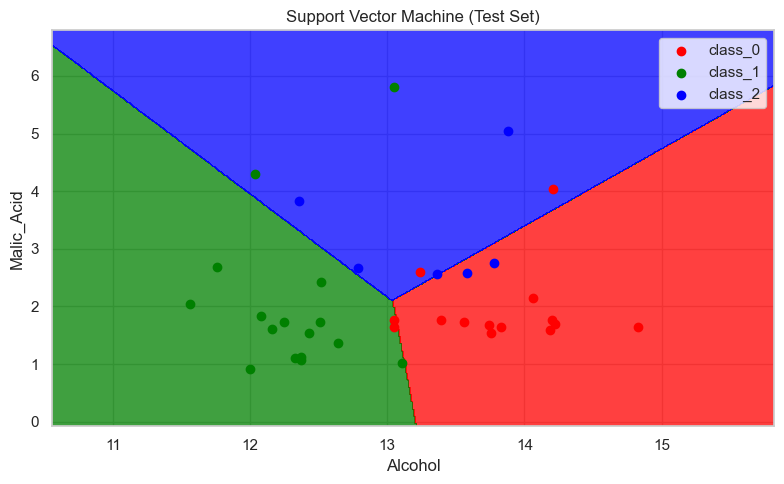

In [10]:
svm = SVC(kernel='linear', random_state=0)
wc.train_and_visualize(svm, "Support Vector Machine")

### Comparison and Conclusion

In [11]:
compare_models(wc)


📊 Model Comparison Summary:



,Model,Accuracy,Precision (macro avg),Recall (macro avg),F1-Score (macro avg)
0,Random Forest,0.888889,0.852778,0.878968,0.860158
1,K-Nearest Neighbors,0.888889,0.852778,0.878968,0.860158
2,Naive Bayes,0.833333,0.770833,0.767857,0.766667
3,Decision Tree,0.805556,0.788889,0.810516,0.781237
4,Support Vector Machine,0.777778,0.736111,0.751984,0.738553
5,Logistic Regression,0.722222,0.669841,0.675595,0.671511



🏆 Best Performing Model: Random Forest
Accuracy: 0.8889
Precision: 0.8528
Recall: 0.8790
F1-Score: 0.8602


,Model,Accuracy,Precision (macro avg),Recall (macro avg),F1-Score (macro avg)
0,Random Forest,0.888889,0.852778,0.878968,0.860158
1,K-Nearest Neighbors,0.888889,0.852778,0.878968,0.860158
2,Naive Bayes,0.833333,0.770833,0.767857,0.766667
3,Decision Tree,0.805556,0.788889,0.810516,0.781237
4,Support Vector Machine,0.777778,0.736111,0.751984,0.738553
5,Logistic Regression,0.722222,0.669841,0.675595,0.671511
